In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sys

sys.path.insert(0, '/mnt/nvme0/home/utbt/KhoaVM/y_DG')
from utils.data import get_dataloaders

In [ ]:
DATASETS = ['OTU', 'USOVA', 'OVATUS']
SPLITS = ['train', 'val', 'test']

loaders = {}
for name in DATASETS:
    train_loader, val_loader, test_loader = get_dataloaders(
        name=name, image_size=256, transform=None,
        batch_size=1, num_workers=0, pin_memory=False,
    )
    loaders[name] = {'train': train_loader, 'val': val_loader, 'test': test_loader}

In [ ]:
N_SHOW = 10  # number of samples per set

for name in DATASETS:
    for split in SPLITS:
        ds = loaders[name][split].dataset
        print(f'=== {name} / {split} (total {len(ds.images)}) ===')
        for i in range(min(N_SHOW, len(ds.images))):
            print(f'  [{i}] x: {ds.images[i]}')
            print(f'      y: {ds.masks[i]}')

In [ ]:
N_SAMPLES = 5  # number of couples (x, y) per split to plot

rng = np.random.default_rng()

for name in DATASETS:
    fig, axes = plt.subplots(len(SPLITS), N_SAMPLES * 2, figsize=(3 * N_SAMPLES * 2, 3 * len(SPLITS)))
    for j, split in enumerate(SPLITS):
        loader = loaders[name][split]
        ds = loader.dataset
        idxs = rng.choice(len(ds), size=N_SAMPLES, replace=False)
        for k, idx in enumerate(idxs):
            x, y = ds[idx]
            x = x.unsqueeze(0)
            y = y.unsqueeze(0)
            img = x[0].permute(1, 2, 0).numpy()
            msk = y[0, 0].numpy()

            ax_img = axes[j, k * 2]
            ax_img.imshow(img)
            ax_img.set_title(f'{name} - {split} #{k + 1} - image')
            ax_img.axis('off')

            ax_msk = axes[j, k * 2 + 1]
            ax_msk.imshow(msk, cmap='gray')
            ax_msk.set_title(f'{name} - {split} #{k + 1} - mask')
            ax_msk.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import torch
from matplotlib.lines import Line2D

from DG.SR_SAM.data import get_sr_sam_target_loader
from DG.SR_SAM.model import build_sr_sam

DEVICE = 'cuda:1' if torch.cuda.is_available() else 'cpu'
MODEL_TYPE = 'vit_b'
SR_CFG = dict(image_size=256, num_classes=1, rank=64, ema_mode=True,
              truncation_size=96, truncation=True)

SINGLE_SOURCE_RUNS = [
    ('OTU', ['OTU', 'OVATUS', 'USOVA']),
    ('OVATUS', ['OVATUS', 'OTU', 'USOVA']),
    ('USOVA', ['USOVA', 'OTU', 'OVATUS']),
]
N_SAMPLES = 5

rng = np.random.default_rng()
legend_handles = [
    Line2D([0], [0], color='green', lw=2, label='GT contour'),
    Line2D([0], [0], color='red', lw=2, label='Pred contour'),
]

for source, targets in SINGLE_SOURCE_RUNS:
    weight_path = f'weights/sr_sam/{MODEL_TYPE}_sr_sam_s_{source}_best.pth'
    model = build_sr_sam(checkpoint=SAM_CKPT, model_type=MODEL_TYPE, **SR_CFG).to(DEVICE)
    model.load_state_dict(torch.load(weight_path, map_location=DEVICE, weights_only=True))
    model.eval()
    print(f'Loaded {weight_path}')

    fig, axes = plt.subplots(len(targets), N_SAMPLES,
                             figsize=(3 * N_SAMPLES, 3 * len(targets)))
    axes = np.atleast_2d(axes)
    for i, target in enumerate(targets):
        loader = get_sr_sam_target_loader(
            target, SR_CFG['image_size'], batch_size=1,
            num_workers=0, pin_memory=False, split='test',
        )
        ds = loader.dataset
        idxs = rng.choice(len(ds), size=N_SAMPLES, replace=False)
        for k, idx in enumerate(idxs):
            x, y, bbox = ds[int(idx)]
            x = x.unsqueeze(0).to(DEVICE)
            bbox = bbox.unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                out = model(x, multimask_output=False, image_size=x.shape[-1],
                            bbox_input=bbox, ema=False)
            pred = (torch.sigmoid(out['masks'].float())[0, 0] > 0.5).cpu().numpy()
            img = x[0].permute(1, 2, 0).cpu().numpy()
            gt = y[0].numpy()

            ax = axes[i, k]
            ax.imshow(img)
            ax.contour(gt, levels=[0.5], colors='green', linewidths=1.5)
            ax.contour(pred, levels=[0.5], colors='red', linewidths=1.5)
            if k == 0:
                ax.set_title(f'{source} (src) -> {target} (tgt)', loc='left', fontsize=10)
            ax.axis('off')

    fig.suptitle(f'SR-SAM ({MODEL_TYPE}) | source: {source}', fontsize=13)
    fig.legend(handles=legend_handles, loc='upper right', ncol=2)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    del model
    torch.cuda.empty_cache()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

DEVICE = 'cuda:1' if torch.cuda.is_available() else 'cpu'
MODEL_TYPE = 'vit_h'
SOURCE = 'OTU'
EPS = 1e-8

# All 32 blocks for ViT-H
BLOCK_IDS = list(range(32))

print(f'Device: {DEVICE}')
lora_path = f'weights/sr_sam/{MODEL_TYPE}_sr_sam_s_{SOURCE}_best.pth'
lora_sd = torch.load(lora_path, map_location='cpu', weights_only=True)
print(f'Loaded {lora_path}')


def block_change_rates(block_id, branch):
    W = lora_sd[f'sam.image_encoder.blocks.{block_id}.attn.qkv.qkv.weight'].float()
    dim = W.shape[1]
    rows = slice(0, dim) if branch == 'q' else slice(-dim, None)
    U, S, Vh = torch.linalg.svd(W[rows].to(DEVICE), full_matrices=False)

    prefix = f'sam.image_encoder.blocks.{block_id}.attn.qkv.'
    out = {}
    for kind, tag in [('ema', 'ema_'), ('lora', '')]:
        A = lora_sd[prefix + tag + f'linear_a_{branch}.weight'].float().to(DEVICE)
        B = lora_sd[prefix + tag + f'linear_b_{branch}.weight'].float().to(DEVICE)
        proj = torch.diag(U.T @ (B @ A) @ Vh.T)
        cr = (proj.abs() / (S.abs() + EPS)).cpu()
        cr_sorted, _ = torch.sort(cr, descending=True)
        out[kind] = cr_sorted.numpy()
    return out


# 32 plots -> 8 rows x 4 columns grid
nrows, ncols = 8, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(24, 32))
axes_flat = axes.flat

for ax, b in zip(axes_flat, BLOCK_IDS):
    layer_name = f'image_encoder.blocks.{b}.attn.qkv.weight'

    for branch, color in [('q', 'tab:blue'), ('v', 'tab:orange')]:
        crs = block_change_rates(b, branch)
        x = np.arange(len(crs['ema']))

        # Linear bar plots
        ax.bar(
            x,
            crs['ema'],
            width=1.0,
            color=color,
            alpha=0.5,
            label=f'{branch.upper()} (EMA LoRA)',
        )
        ax.bar(
            x,
            crs['lora'],
            width=1.0,
            color=color,
            alpha=0.2,
            edgecolor=color,
            linewidth=0.5,
            label=f'{branch.upper()} (LoRA)',
        )

    ax.set_title(layer_name, fontsize=9)
    ax.set_xlabel('Rank', fontsize=8)
    ax.set_ylabel(r'$\delta_i$', fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=8)

# Single shared legend at the top
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.995),
    fontsize=12,
)
fig.suptitle(
    f'SR-SAM ({MODEL_TYPE}) Change-Rate Distribution Across All Encoder Layers | Source: {SOURCE}',
    fontsize=16,
    y=1.002,
)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

# Correlations between Q, V, Q_ema, V_ema of 1 layer after epochs

In [1]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
MODEL_TYPE = "vit_h"
SOURCE = "OTU"
EPS = 1e-8

BLOCKS = [1, 10, 20, 30]
print(f'Device: {DEVICE}')

# ---------------------------------------------------------
# TỰ ĐỘNG ĐỌC EPOCH (BỎ QUA FILE KHÔNG TỒN TẠI)
# ---------------------------------------------------------
EPOCHS_TO_CHECK = list(range(1, 161))
EPOCHS = []
lora_sds = {}

for ep in EPOCHS_TO_CHECK:
    # lora_path = f"weights/sr_sam/sr_sam_{MODEL_TYPE}_experiment_{SOURCE}_epoch_{ep}.pth"
    lora_path = f"weights/dsr_sam/dsr_sam_{MODEL_TYPE}_experiment_{SOURCE}_epoch_{ep}.pth"

    if os.path.exists(lora_path):
        lora_sds[ep] = torch.load(lora_path, map_location="cpu", weights_only=True)
        EPOCHS.append(ep)
        print(f"Loaded {lora_path}")
        
if not EPOCHS:
    raise FileNotFoundError("Không tìm thấy bất kỳ file trọng số nào! Vui lòng kiểm tra lại đường dẫn.")

print(f"Danh sách các Epochs sẽ được vẽ: {EPOCHS}")
# ---------------------------------------------------------

Device: cuda:0
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_1.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_2.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_3.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_4.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_5.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_6.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_7.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_8.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_9.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_10.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_11.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_12.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_13.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_14.pth
Loaded weights/dsr_sam/dsr_sam_vit_h_experiment_OTU_epoch_15.pth
Loaded weights/dsr_

In [ ]:
def compute_matrix_self_cosine_sim(block_id, branch, matrix_type, lora_sd, target_size='r', is_ema=False):
    """
    Compute absolute cosine similarity for A or B matrix with specific target size (r or dim).
    """
    tag = "ema_" if is_ema else ""
    prefix = f"sam.image_encoder.blocks.{block_id}.attn.qkv.{tag}"

    with torch.no_grad():
        weight_key = prefix + f"linear_{matrix_type}_{branch}.weight"
        M = lora_sd[weight_key].float().to(DEVICE)
        
        # Trong PyTorch: Linear A có shape (r, dim), Linear B có shape (dim, r)
        if matrix_type == "a":
            if target_size == "r":
                # Tính tương đồng giữa các hàng của A -> r x r
                norm_M = F.normalize(M, p=2, dim=1)
                sim_tensor = norm_M @ norm_M.T
            else:
                # Tính tương đồng giữa các cột của A -> dim x dim
                norm_M = F.normalize(M, p=2, dim=0)
                sim_tensor = norm_M.T @ norm_M
        else: # matrix_type == "b"
            if target_size == "r":
                # Tính tương đồng giữa các cột của B -> r x r
                norm_M = F.normalize(M, p=2, dim=0)
                sim_tensor = norm_M.T @ norm_M
            else:
                # Tính tương đồng giữa các hàng của B -> dim x dim
                norm_M = F.normalize(M, p=2, dim=1)
                sim_tensor = norm_M @ norm_M.T

        sim_matrix = sim_tensor.abs().cpu().numpy()
        del M, norm_M, sim_tensor

    if 'cuda' in DEVICE:
        torch.cuda.empty_cache()
    gc.collect()
    return sim_matrix


# ---------------------------------------------------------
# Layout setup
# 4 blocks (r x r) * Số Epochs thực tế
# ---------------------------------------------------------
nrows = len(BLOCKS) * len(EPOCHS)
ncols = 8

# Width được giữ 32, Height linh hoạt theo số hàng (Rất dài)
fig, axes = plt.subplots(nrows, ncols, figsize=(32, 4.0 * nrows))
last_im = None

col_configs = [
    ("q", "a", False, "A_Q"),
    ("q", "b", False, "B_Q"),
    ("q", "a", True,  "A_Q_ema"),
    ("q", "b", True,  "B_Q_ema"),
    ("v", "a", False, "A_V"),
    ("v", "b", False, "B_V"),
    ("v", "a", True,  "A_V_ema"),
    ("v", "b", True,  "B_V_ema"),
]

row_idx = 0

# Duyệt qua từng Block
for b in BLOCKS:
    # Bước 1: Vẽ Epochs cho kích cỡ (r x r)
    for target_size in ['r']:
        for ep in EPOCHS:
            lora_sd = lora_sds[ep]
            
            for col_idx, (branch, mat_type, is_ema, label) in enumerate(col_configs):
                ax = axes[row_idx, col_idx]
                
                sim = compute_matrix_self_cosine_sim(b, branch, mat_type, lora_sd, target_size=target_size, is_ema=is_ema)
                
                last_im = ax.imshow(
                    sim, cmap="viridis", vmin=0.0, vmax=1.0, origin="lower", aspect="equal"
                )
                del sim
                gc.collect()

                # Thiết lập Title rõ ràng hiển thị r x r hay dim x dim
                title = f"Block {b} | Epoch {ep}"
                
                # Ghi chú loại ma trận ở đầu mỗi cột của toàn bộ Figure
                if row_idx == 0:
                    title = f"--- {label} ---\n\n{title}"
                    
                ax.set_title(title, fontsize=12, fontweight="bold")
                ax.set_xlabel("Index", fontsize=9, fontweight="bold")
                ax.set_ylabel("Index", fontsize=9, fontweight="bold")
                ax.tick_params(axis="both", which="major", labelsize=8)
            
            row_idx += 1

# Colorbar chung bên phải
fig.subplots_adjust(right=0.92, top=0.99, hspace=0.4, wspace=0.3)
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
cbar = fig.colorbar(last_im, cax=cbar_ax)
cbar.set_label("Absolute Cosine Similarity ([0.0, 1.0])", fontsize=14, fontweight="bold")
cbar.ax.tick_params(labelsize=12)

fig.suptitle(
    f"SR-SAM ({MODEL_TYPE}) A & B Matrix Absolute Self-Similarity Across Epochs\n"
    f"Blocks {BLOCKS} | Source: {SOURCE}",
    fontsize=18,
    fontweight="bold",
    y=0.998,
)

plt.tight_layout(rect=[0, 0, 0.92, 0.995])

# =========================================================
# THÊM CODE TỰ ĐỘNG LƯU HÌNH Ở ĐÂY
# =========================================================
# 1. Tạo tên file động 
blocks_str = "-".join(map(str, BLOCKS))
ep_start, ep_end = EPOCHS[0], EPOCHS[-1]
save_filename = f"SelfSim_AB_{MODEL_TYPE}_{SOURCE}_Blocks_{blocks_str}_Ep_{ep_start}to{ep_end}.png"

# 2. Tạo thư mục 'saved_plots' 
save_dir = "saved_plots"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, save_filename)

# 3. Lưu ảnh
plt.savefig(save_path, dpi=100, bbox_inches='tight', facecolor='white')
print(f"✅ Đã lưu biểu đồ thành công tại: {save_path}")
# =========================================================

In [ ]:
def compute_change_rates(block_id, branch, lora_sd):
    """
    Compute change rates per SR-SAM paper:
    change_rate_i = u_i^T @ deltaW @ v_i / (S_i + eps)
    - deltaW = B_ema @ A_ema (EMA LoRA)
    - u_i, v_i from SVD of SR-SAM's W (qkv.weight), NOT pretrained SAM
    """
    # Weight key from SR-SAM model (qkv.weight after LoRA merge)
    W_key = f'sam.image_encoder.blocks.{block_id}.attn.qkv.qkv.weight'
    W = lora_sd[W_key].float()
    dim = W.shape[1]
    rows = slice(0, dim) if branch == 'q' else slice(-dim, None)
    W_branch = W[rows].to(DEVICE)

    # SVD of SR-SAM weight (not pretrained)
    U, S, Vh = torch.linalg.svd(W_branch, full_matrices=False)
    V = Vh.T  # Vh is V^T, so V = Vh.T

    # EMA LoRA deltaW = B_ema @ A_ema
    prefix = f'sam.image_encoder.blocks.{block_id}.attn.qkv.'
    A_ema = lora_sd[prefix + f'ema_linear_a_{branch}.weight'].float().to(DEVICE)
    B_ema = lora_sd[prefix + f'ema_linear_b_{branch}.weight'].float().to(DEVICE)
    deltaW = B_ema @ A_ema  # (dim, r) @ (r, dim) -> (dim, dim)

    # change_rate_i = u_i^T @ deltaW @ v_i / (S_i + eps)
    # u_i = U[:, i], v_i = V[:, i]
    # Equivalent to: diag(U.T @ deltaW @ V) / (S + eps)
    proj = torch.diag(U.T @ deltaW @ V)
    change_rates = (proj.abs() / (S.abs() + EPS)).cpu().numpy()

    del W, W_branch, U, S, Vh, V, A_ema, B_ema, deltaW, proj
    if 'cuda' in DEVICE:
        torch.cuda.empty_cache()
    gc.collect()
    return change_rates


# =========================================================
# PLOT CHANGE RATES ACROSS EPOCHS
# =========================================================
TOP_K = 100  # số giá trị change rate cao nhất để plot
EPOCHS_PER_ROW = 6  # số epoch mỗi hàng

for b in BLOCKS:
    n_epochs = len(EPOCHS)
    n_rows = int(np.ceil(n_epochs / EPOCHS_PER_ROW))
    
    fig, axes = plt.subplots(n_rows, EPOCHS_PER_ROW, 
                            figsize=(4 * EPOCHS_PER_ROW, 3.5 * n_rows),
                            squeeze=False)
    
    for row_idx in range(n_rows):
        for col_idx in range(EPOCHS_PER_ROW):
            ep_idx = row_idx * EPOCHS_PER_ROW + col_idx
            ax = axes[row_idx, col_idx]
            
            if ep_idx >= n_epochs:
                ax.axis('off')
                continue
            
            ep = EPOCHS[ep_idx]
            lora_sd = lora_sds[ep]
            
            for branch, color, label in [('q', 'tab:blue', 'Q (EMA)'), ('v', 'tab:orange', 'V (EMA)')]:
                cr = compute_change_rates(b, branch, lora_sd)
                cr_sorted = np.sort(cr)[::-1][:TOP_K]  # sort descending, take top 100
                x = np.arange(len(cr_sorted))
                ax.bar(x, cr_sorted, width=1.0, color=color, alpha=0.6, 
                     label=label, edgecolor='none')
            
            ax.set_title(f'Block {b} | Epoch {ep}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Rank (sorted)', fontsize=9)
            ax.set_ylabel('Change Rate', fontsize=9)
            ax.tick_params(axis='both', labelsize=8)
            ax.set_yscale('linear')  # không dùng log scale
            ax.grid(True, alpha=0.3, axis='y')
    
    # Legend chung cho figure này
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, 
              bbox_to_anchor=(0.5, 0.98), fontsize=11)
    
    fig.suptitle(f'SR-SAM ({MODEL_TYPE}) Change Rates | Block {b} | Source: {SOURCE} | Top {TOP_K}', 
               fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Lưu figure
    save_dir = "saved_plots"
    os.makedirs(save_dir, exist_ok=True)
    save_filename = f"ChangeRate_{MODEL_TYPE}_{SOURCE}_Block{b}_Top{TOP_K}.png"
    save_path = os.path.join(save_dir, save_filename)
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"✅ Đã lưu: {save_path}")
    
    plt.show()
    plt.close(fig)
    gc.collect()

In [ ]:
def compute_matrix_self_cosine_sim_lora(block_id, branch, matrix_type, lora_sd, target_size='r'):
    """
    Compute absolute cosine similarity for A or B matrix with specific target size (r or dim).
    Standard LoRA only (no EMA).
    """
    prefix = f"sam.image_encoder.blocks.{block_id}.attn.qkv."

    with torch.no_grad():
        weight_key = prefix + f"linear_{matrix_type}_{branch}.weight"
        M = lora_sd[weight_key].float().to(DEVICE)

        # Trong PyTorch: Linear A có shape (r, dim), Linear B có shape (dim, r)
        if matrix_type == "a":
            if target_size == "r":
                # Tính tương đồng giữa các hàng của A -> r x r
                norm_M = F.normalize(M, p=2, dim=1)
                sim_tensor = norm_M @ norm_M.T
            else:
                # Tính tương đồng giữa các cột của A -> dim x dim
                norm_M = F.normalize(M, p=2, dim=0)
                sim_tensor = norm_M.T @ norm_M
        else: # matrix_type == "b"
            if target_size == "r":
                # Tính tương đồng giữa các cột của B -> r x r
                norm_M = F.normalize(M, p=2, dim=0)
                sim_tensor = norm_M.T @ norm_M
            else:
                # Tính tương đồng giữa các hàng của B -> dim x dim
                norm_M = F.normalize(M, p=2, dim=1)
                sim_tensor = norm_M @ norm_M.T

        sim_matrix = sim_tensor.abs().cpu().numpy()
        del M, norm_M, sim_tensor

    if 'cuda' in DEVICE:
        torch.cuda.empty_cache()
    gc.collect()
    return sim_matrix


# ---------------------------------------------------------
# Layout setup
# 4 blocks (r x r) * Số Epochs thực tế
# Standard LoRA only: 4 columns (A_Q, B_Q, A_V, B_V)
# ---------------------------------------------------------
nrows = len(BLOCKS) * len(EPOCHS)
ncols = 4

# Width giữ cùng tỉ lệ mỗi panel như bản 8 cột (4.0 width/panel), Height linh hoạt theo số hàng (Rất dài)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.0 * nrows))
axes = np.atleast_2d(axes)
last_im = None

col_configs = [
    ("q", "a", "A_Q"),
    ("q", "b", "B_Q"),
    ("v", "a", "A_V"),
    ("v", "b", "B_V"),
]

row_idx = 0

# Duyệt qua từng Block
for b in BLOCKS:
    # Bước 1: Vẽ Epochs cho kích cỡ (r x r)
    for target_size in ['r']:
        for ep in EPOCHS:
            lora_sd = lora_sds[ep]

            for col_idx, (branch, mat_type, label) in enumerate(col_configs):
                ax = axes[row_idx, col_idx]

                sim = compute_matrix_self_cosine_sim_lora(b, branch, mat_type, lora_sd, target_size=target_size)

                last_im = ax.imshow(
                    sim, cmap="viridis", vmin=0.0, vmax=1.0, origin="lower", aspect="equal"
                )
                del sim
                gc.collect()

                # Thiết lập Title rõ ràng hiển thị r x r hay dim x dim
                title = f"Block {b} | Epoch {ep}"

                # Ghi chú loại ma trận ở đầu mỗi cột của toàn bộ Figure
                if row_idx == 0:
                    title = f"--- {label} ---\n\n{title}"

                ax.set_title(title, fontsize=12, fontweight="bold")
                ax.set_xlabel("Index", fontsize=9, fontweight="bold")
                ax.set_ylabel("Index", fontsize=9, fontweight="bold")
                ax.tick_params(axis="both", which="major", labelsize=8)

            row_idx += 1

# Colorbar chung bên phải
fig.subplots_adjust(right=0.92, top=0.99, hspace=0.4, wspace=0.3)
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
cbar = fig.colorbar(last_im, cax=cbar_ax)
cbar.set_label("Absolute Cosine Similarity ([0.0, 1.0])", fontsize=14, fontweight="bold")
cbar.ax.tick_params(labelsize=12)

fig.suptitle(
    f"SR-SAM ({MODEL_TYPE}) A & B Matrix Absolute Self-Similarity Across Epochs (Standard LoRA only)\n"
    f"Blocks {BLOCKS} | Source: {SOURCE}",
    fontsize=18,
    fontweight="bold",
    y=0.998,
)

plt.tight_layout(rect=[0, 0, 0.92, 0.995])

# =========================================================
# THÊM CODE TỰ ĐỘNG LƯU HÌNH Ở ĐÂY
# =========================================================
# 1. Tạo tên file động
blocks_str = "-".join(map(str, BLOCKS))
ep_start, ep_end = EPOCHS[0], EPOCHS[-1]
save_filename = f"SelfSim_AB_LoRAonly_{MODEL_TYPE}_{SOURCE}_Blocks_{blocks_str}_Ep_{ep_start}to{ep_end}.png"

# 2. Tạo thư mục 'saved_plots'
save_dir = "saved_plots"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, save_filename)

# 3. Lưu ảnh
plt.savefig(save_path, dpi=100, bbox_inches='tight', facecolor='white')
print(f"✅ Đã lưu biểu đồ thành công tại: {save_path}")
# =========================================================

/tmp/ipykernel_1956578/2882800680.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 0.995])


✅ Đã lưu biểu đồ thành công tại: saved_plots/SelfSim_AB_LoRAonly_vit_h_OTU_Blocks_1-10-20-30_Ep_1to20.png


✅ Đã lưu: saved_plots/ChangeRate_LoRAonly_vit_h_OTU_Block1_Top100.png


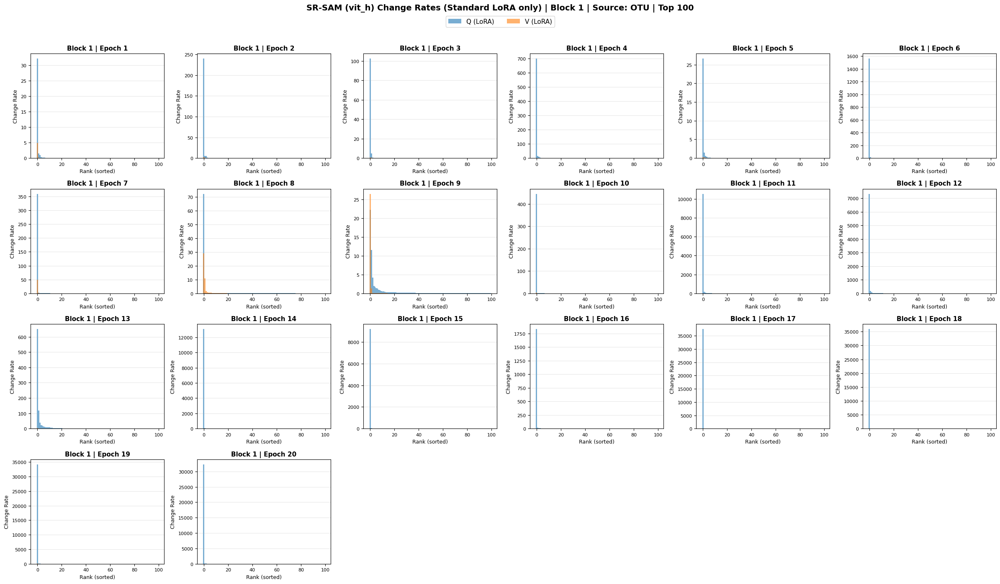

✅ Đã lưu: saved_plots/ChangeRate_LoRAonly_vit_h_OTU_Block10_Top100.png


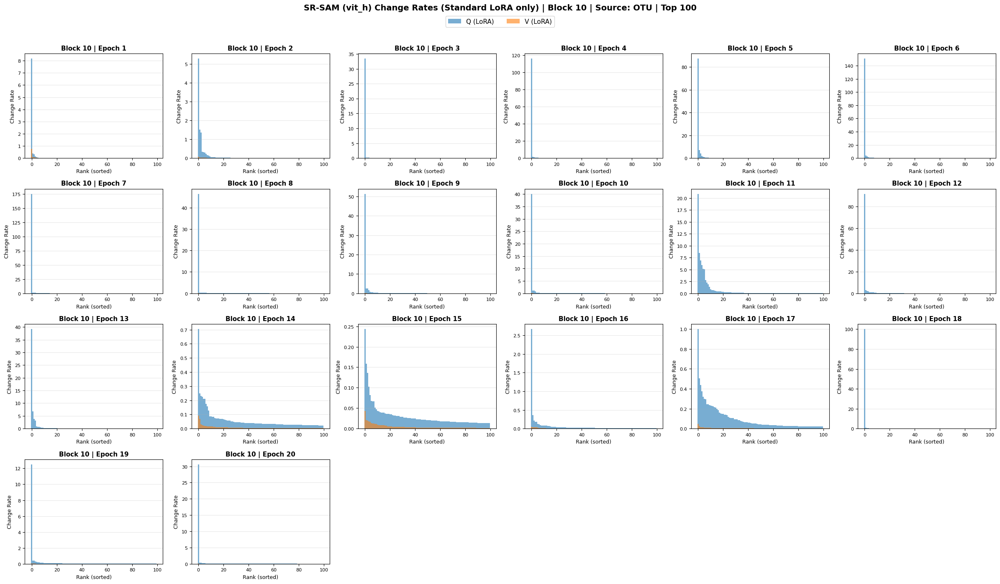

✅ Đã lưu: saved_plots/ChangeRate_LoRAonly_vit_h_OTU_Block20_Top100.png


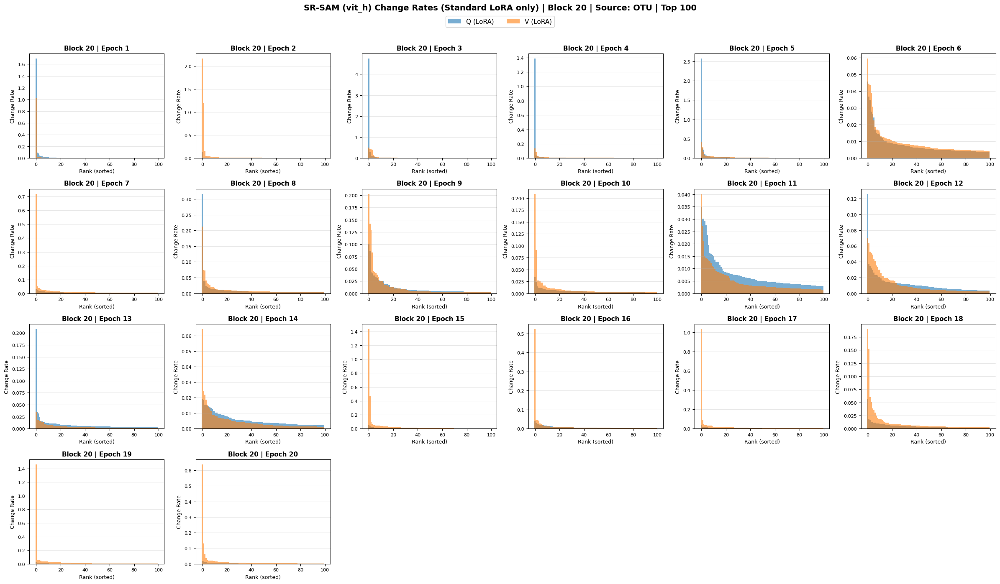

✅ Đã lưu: saved_plots/ChangeRate_LoRAonly_vit_h_OTU_Block30_Top100.png


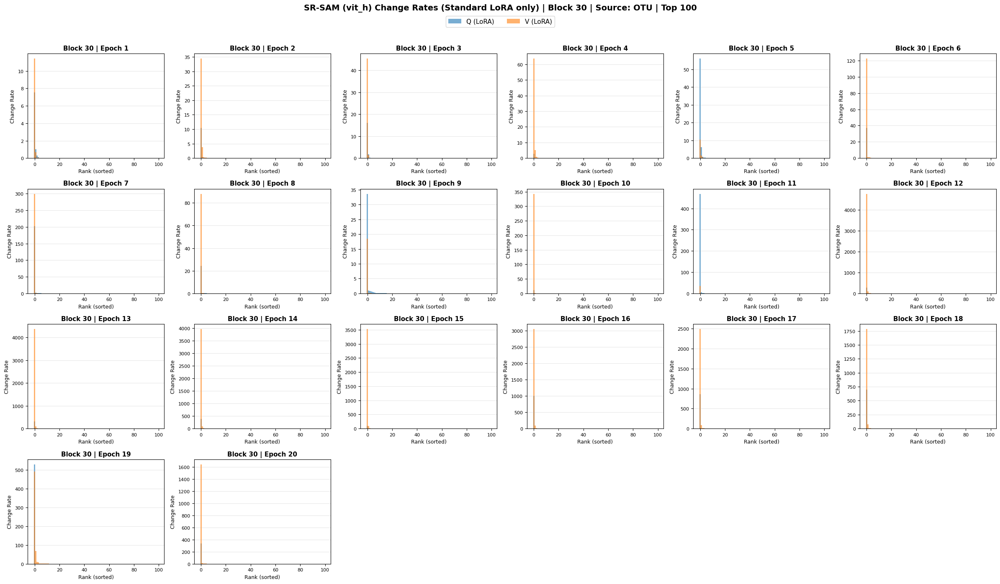

In [3]:
def compute_change_rates_lora(block_id, branch, lora_sd):
    """
    Compute change rates per SR-SAM paper:
    change_rate_i = u_i^T @ deltaW @ v_i / (S_i + eps)
    - deltaW = B @ A (Standard LoRA, no EMA)
    - u_i, v_i from SVD of SR-SAM's W (qkv.weight), NOT pretrained SAM
    """
    # Weight key from SR-SAM model (qkv.weight after LoRA merge)
    W_key = f'sam.image_encoder.blocks.{block_id}.attn.qkv.qkv.weight'
    W = lora_sd[W_key].float()
    dim = W.shape[1]
    rows = slice(0, dim) if branch == 'q' else slice(-dim, None)
    W_branch = W[rows].to(DEVICE)

    # SVD of SR-SAM weight (not pretrained)
    U, S, Vh = torch.linalg.svd(W_branch, full_matrices=False)
    V = Vh.T  # Vh is V^T, so V = Vh.T

    # Standard LoRA deltaW = B @ A
    prefix = f'sam.image_encoder.blocks.{block_id}.attn.qkv.'
    A = lora_sd[prefix + f'linear_a_{branch}.weight'].float().to(DEVICE)
    B = lora_sd[prefix + f'linear_b_{branch}.weight'].float().to(DEVICE)
    deltaW = B @ A  # (dim, r) @ (r, dim) -> (dim, dim)

    # change_rate_i = u_i^T @ deltaW @ v_i / (S_i + eps)
    # u_i = U[:, i], v_i = V[:, i]
    # Equivalent to: diag(U.T @ deltaW @ V) / (S + eps)
    proj = torch.diag(U.T @ deltaW @ V)
    change_rates = (proj.abs() / (S.abs() + EPS)).cpu().numpy()

    del W, W_branch, U, S, Vh, V, A, B, deltaW, proj
    if 'cuda' in DEVICE:
        torch.cuda.empty_cache()
    gc.collect()
    return change_rates


# =========================================================
# PLOT CHANGE RATES ACROSS EPOCHS (Standard LoRA only)
# =========================================================
TOP_K = 100  # số giá trị change rate cao nhất để plot
EPOCHS_PER_ROW = 6  # số epoch mỗi hàng

for b in BLOCKS:
    n_epochs = len(EPOCHS)
    n_rows = int(np.ceil(n_epochs / EPOCHS_PER_ROW))

    fig, axes = plt.subplots(n_rows, EPOCHS_PER_ROW,
                            figsize=(4 * EPOCHS_PER_ROW, 3.5 * n_rows),
                            squeeze=False)

    for row_idx in range(n_rows):
        for col_idx in range(EPOCHS_PER_ROW):
            ep_idx = row_idx * EPOCHS_PER_ROW + col_idx
            ax = axes[row_idx, col_idx]

            if ep_idx >= n_epochs:
                ax.axis('off')
                continue

            ep = EPOCHS[ep_idx]
            lora_sd = lora_sds[ep]

            for branch, color, label in [('q', 'tab:blue', 'Q (LoRA)'), ('v', 'tab:orange', 'V (LoRA)')]:
                cr = compute_change_rates_lora(b, branch, lora_sd)
                cr_sorted = np.sort(cr)[::-1][:TOP_K]  # sort descending, take top 100
                x = np.arange(len(cr_sorted))
                ax.bar(x, cr_sorted, width=1.0, color=color, alpha=0.6,
                     label=label, edgecolor='none')

            ax.set_title(f'Block {b} | Epoch {ep}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Rank (sorted)', fontsize=9)
            ax.set_ylabel('Change Rate', fontsize=9)
            ax.tick_params(axis='both', labelsize=8)
            ax.set_yscale('linear')  # không dùng log scale
            ax.grid(True, alpha=0.3, axis='y')

    # Legend chung cho figure này
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2,
              bbox_to_anchor=(0.5, 0.98), fontsize=11)

    fig.suptitle(f'SR-SAM ({MODEL_TYPE}) Change Rates (Standard LoRA only) | Block {b} | Source: {SOURCE} | Top {TOP_K}',
               fontsize=14, fontweight='bold', y=0.995)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Lưu figure
    save_dir = "saved_plots"
    os.makedirs(save_dir, exist_ok=True)
    save_filename = f"ChangeRate_LoRAonly_{MODEL_TYPE}_{SOURCE}_Block{b}_Top{TOP_K}.png"
    save_path = os.path.join(save_dir, save_filename)
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"✅ Đã lưu: {save_path}")

    plt.show()
    plt.close(fig)
    gc.collect()